In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

Loading and Preprocessing data

In [30]:
file_path = 'Retail_Prices_of _Products.csv'
df = pd.read_csv(file_path)
df['date']       = pd.to_datetime(df['Year'].astype(str) + ' ' + df['Month'], format='%Y %B')
df['Province']   = df['GEO'].str.strip()
df['Price']      = pd.to_numeric(df['VALUE'], errors='coerce')
df = df.dropna(subset=['date','Province','Price'])
df['Quarter']    = df['date'].dt.to_period('Q')
df['Month_Num']  = df['date'].dt.month
df['Quarter_Num']= df['date'].dt.quarter

Checking if dataset have missing or duplicate data

In [31]:
missing_report = df.isna().sum()

print("\nMissing-value count for each column")
for col, n_miss in missing_report.items():
    print(f"{col:<20} : {n_miss}")

dup_count = df.duplicated().sum()
print(f"\nTotal duplicate rows : {dup_count}")


Missing-value count for each column
Year                 : 0
Month                : 0
GEO                  : 0
Product Category     : 0
Products             : 0
VALUE                : 0
Taxable              : 0
Total tax rate       : 0
Value after tax      : 0
Essential            : 0
COORDINATE           : 0
UOM                  : 0
date                 : 0
Province             : 0
Price                : 0
Quarter              : 0
Month_Num            : 0
Quarter_Num          : 0

Total duplicate rows : 0


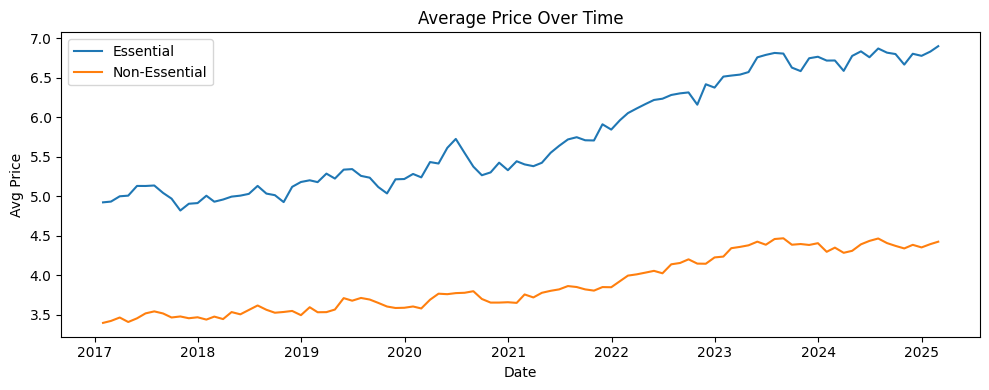

In [32]:
cpi = (
    df
    .groupby([pd.Grouper(key='date', freq='ME'), 'Essential'])['Price']
    .mean()
    .reset_index()
)
plt.figure(figsize=(10,4))
for category, grp in cpi.groupby('Essential'):
    plt.plot(grp['date'], grp['Price'], label=category)
plt.title('Average Price Over Time')
plt.xlabel('Date'); plt.ylabel('Avg Price')
plt.legend(); plt.tight_layout(); plt.show()

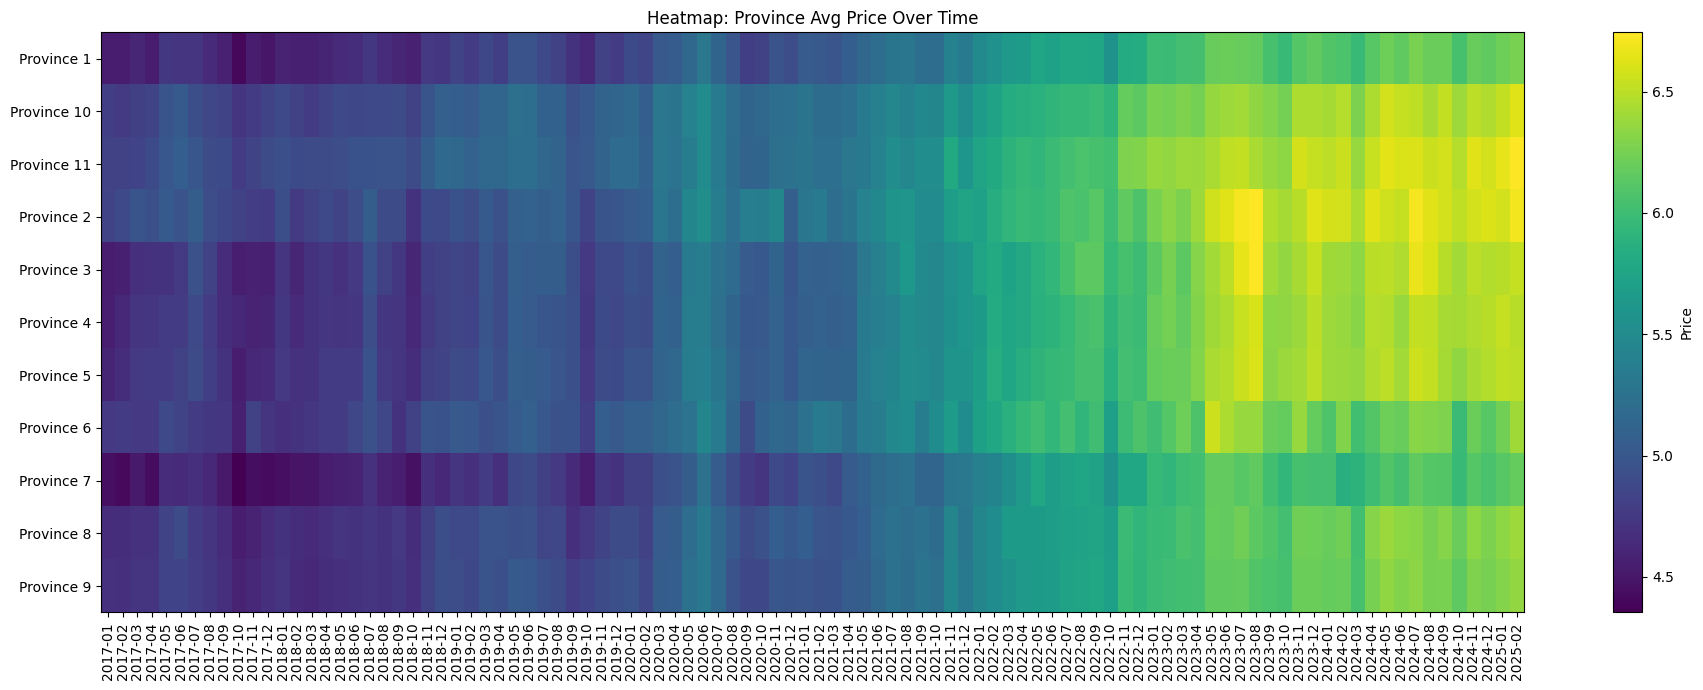

In [33]:
pivot_heat = (
    df
    .groupby([df['date'].dt.to_period('M'), 'Province'])['Price']
    .mean()
    .unstack(fill_value=0)
)
plt.figure(figsize=(19,7))
plt.imshow(pivot_heat.T, aspect='auto')
plt.xticks(range(len(pivot_heat.index)), pivot_heat.index.astype(str), rotation=90)
plt.yticks(range(len(pivot_heat.columns)), pivot_heat.columns)
plt.title('Heatmap: Province Avg Price Over Time')
plt.colorbar(label='Price'); plt.tight_layout(); plt.show()

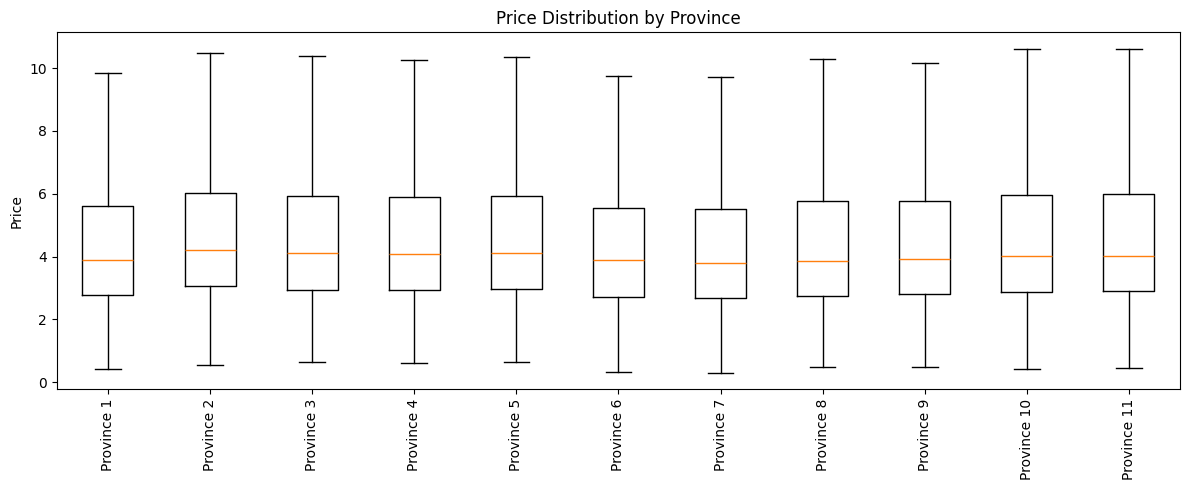

In [34]:
plt.figure(figsize=(12,5))
data_by_prov = [df[df['Province']==prov]['Price'] for prov in df['Province'].unique()]
plt.boxplot(data_by_prov, tick_labels=df['Province'].unique(), showfliers=False)
plt.xticks(rotation=90); plt.title('Price Distribution by Province')
plt.ylabel('Price'); plt.tight_layout(); plt.show()

Testing for differences across provinces using ANOVA

In [35]:
groups = [grp['Price'].values for _, grp in df.groupby('Province')]
f_stat, p_val = f_oneway(*groups)
print(f'ANOVA — F = {f_stat:.2f},  p = {p_val:.4f}')

ANOVA — F = 6.31,  p = 0.0000


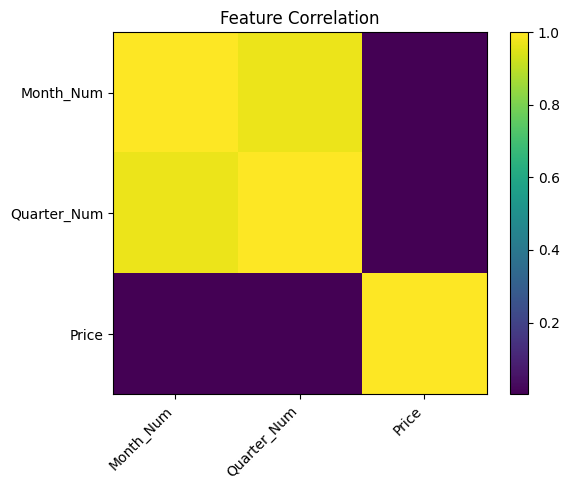

In [36]:
corr = df[['Month_Num','Quarter_Num','Price']].corr()
plt.figure(figsize=(6,5))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Feature Correlation')
plt.tight_layout(); plt.show()

Histogram + KDE on Essential and Non-Essential Products

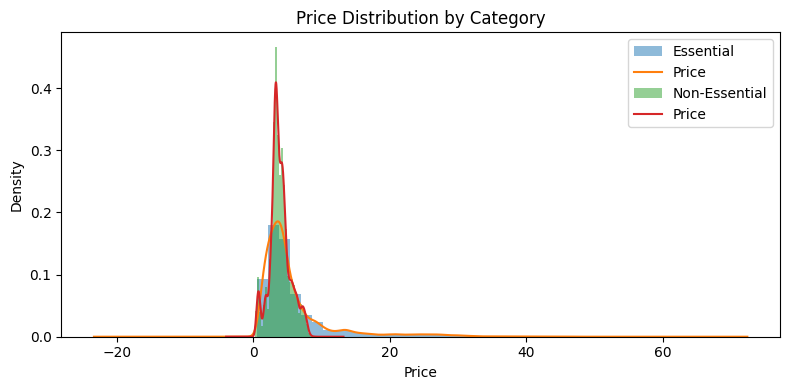

In [37]:
plt.figure(figsize=(8,4))
for flag in ['Essential','Non-Essential']:
    data = df[df['Essential']==flag]['Price']
    plt.hist(data, bins=30, density=True, alpha=0.5, label=flag)
    data.plot.kde()
plt.title('Price Distribution by Category')
plt.xlabel('Price'); plt.ylabel('Density')
plt.legend(); plt.tight_layout(); plt.show()

K-Means Clustering

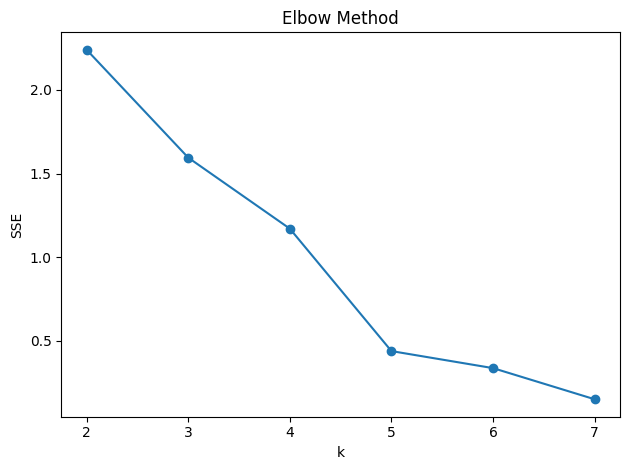

In [38]:
pivot_clust = (
    df
    .groupby(['Province', df['date'].dt.to_period('Q')])['Price']
    .mean()
    .unstack(fill_value=0)
)
X = pivot_clust.values
quarters = pivot_clust.columns.astype(str)

ks = range(2,8)
sse = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    sse.append(km.inertia_)
plt.figure(); plt.plot(list(ks), sse, '-o')
plt.title('Elbow Method'); plt.xlabel('k'); plt.ylabel('SSE')
plt.tight_layout(); plt.show()

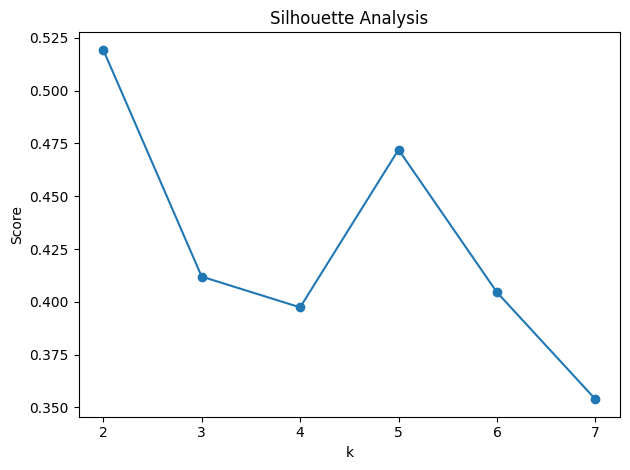

In [39]:
sil = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    sil.append(silhouette_score(X, km.labels_))
plt.figure(); plt.plot(list(ks), sil, '-o')
plt.title('Silhouette Analysis'); plt.xlabel('k'); plt.ylabel('Score')
plt.tight_layout(); plt.show()

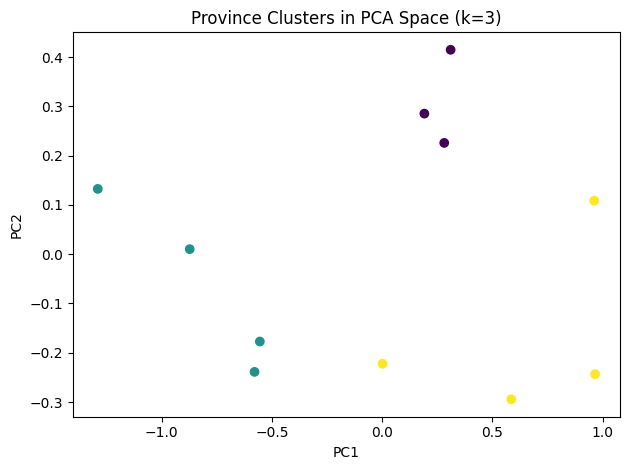

In [40]:
best_k = 3
km3 = KMeans(n_clusters=best_k, random_state=42).fit(X)
labels = km3.labels_
coords = PCA(2).fit_transform(X)
plt.figure(); plt.scatter(coords[:,0], coords[:,1], c=labels)
plt.title(f'Province Clusters in PCA Space (k={best_k})')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.tight_layout(); plt.show()

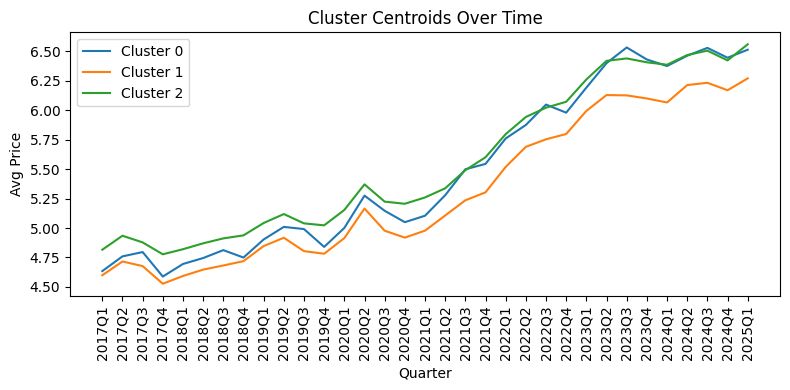


Province → Cluster assignments:
Province
Province 1     1
Province 10    2
Province 11    2
Province 2     2
Province 3     0
Province 4     0
Province 5     0
Province 6     2
Province 7     1
Province 8     1
Province 9     1
Name: Cluster, dtype: int32


In [41]:
centroids = km3.cluster_centers_
plt.figure(figsize=(8,4))
for i, c in enumerate(centroids):
    plt.plot(quarters, c, label=f'Cluster {i}')
plt.title('Cluster Centroids Over Time')
plt.xlabel('Quarter'); plt.ylabel('Avg Price')
plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()

pivot_clust['Cluster'] = labels
print("\nProvince → Cluster assignments:")
print(pivot_clust['Cluster'])

Time-series Forecasting using ARIMA


ARIMA RMSE: 0.10, MAE: 0.09, MAPE: 1.32%


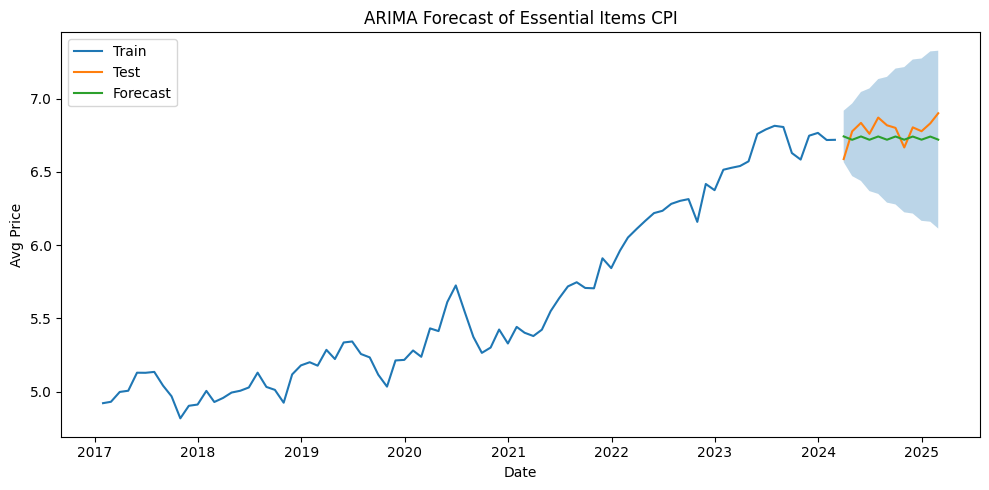

In [42]:
series = (
    df[df['Essential'] == 'Essential']
    .groupby(pd.Grouper(key='date', freq='ME'))['Price']
    .mean()
    .dropna()
)
if len(series) >= 24:
    train, test = series[:-12], series[-12:]
    model = ARIMA(train, order=(1, 1, 1), enforce_stationarity=False, enforce_invertibility=False).fit()
    fc = model.get_forecast(12)
    forecast = fc.predicted_mean
    ci = fc.conf_int()

    rmse = np.sqrt(mean_squared_error(test, forecast))
    mae  = mean_absolute_error(test, forecast)
    mape = np.mean(np.abs((test-forecast)/test))*100
    print(f"\nARIMA RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")

    plt.figure(figsize=(10,5))
    plt.plot(train.index, train, label='Train')
    plt.plot(test.index, test, label='Test')
    plt.plot(forecast.index, forecast, label='Forecast')
    plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.3)
    plt.title('ARIMA Forecast of Essential Items CPI')
    plt.xlabel('Date'); plt.ylabel('Avg Price')
    plt.legend(); plt.tight_layout(); plt.show()
else:
    print(f"Skipping ARIMA: need ≥24 points, got {len(series)}")